# Изолинии вещественной и мнимой частей многочлена

**Задача 1.3.** На комплексной плоскости построить изолинии вещественной и мнимой частей многочлена $P(z)=z^3+(i\cdot m)\cdot z^2-kz+1$. Область рисунка должна включать все три корня многочлена. Нужно описать метод построения.

Муравьёв Герман

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%config InlineBackend.figure_format = 'retina'

# Постоянные
m = 2
k = 17

# Палитра
maroon     = [0.2078, 0.3608, 0.4902] # вещественная часть
red        = [0.7529, 0.4235, 0.5176] # мнимая часть
cream      = [0.8000, 0.8000, 0.8000] # серая сетка
background = [1.0000, 1.0000, 1.0000]

### Решение

Рассмотрим многочлен:
$$
P(z)=z^3+(i\cdot m)\cdot z^2-kz+1,
$$

и выразим вещественную и мнимую части через координаты $a$ и $b$ числа $z=a+bi$. Затем вычислим корни, выберем прямоугольник и построим изолинии.

##### Находим вещественную и мнимую части

Пусть комплексное число вида $z=a+bi$, где $a,b\in\mathbb R$. Число $a$ называется вещественной частью, $b$ – мнимой частью. Введем специальный объект i, который будем называть мнимой единицей, для которого введем правило умножения: $i^2=-1$.

Для начала представим $z^3$ как произведение квадрата на комплексное число вида $z^3 = z^2 \cdot z$. По этой формуле ФСУ, разложим комплексное число, вида $z^2$:

$$
z^2=(a+bi)^2=a^2 +2abi - b^2.
$$

Умножим полученное выражение на z, комплексное число вида $z=a+bi$:

$$
\begin{aligned}
z^3&=(a^2 +2abi - b^2)(a+bi)\\
&=a^3-ab^2+(a^2b-b^3)i+2a^2bi-2ab^2\\
&= a^3-3ab^2+(3a^2b-b^3)i.
\end{aligned}
$$

Отдельно вычислим два остальных слагаемых:

$$
imz^2=im(a^2 +2abi - b^2)=-2mab+m(a^2-b^2)i,
$$

$$
-kz=-ka-kbi.
$$

Сложим вещественные и мнимые части по формуле сложения комплексных чисел:
$$
(a+bi)+(c+di) = (a+c) + (b + d)i
$$

имеем:

$$
P(a+bi)=\bigl(a^3-3ab^2-2mab-ka+1\bigr)
+i\bigl(3a^2b-b^3+m(a^2-b^2)-kb\bigr).
$$

Подставив постоянные: $m=2$, $k=17$ получаем:
$$
\begin{align*}
\operatorname{Re}P(a+bi)=a^3-3ab^2-4ab-17a+1, \\
\operatorname{Im}P(a+bi)=3a^2b-b^3+2a^2-2b^2-17b.
\end{align*}
$$

In [10]:
def P(z):
    return z**3 + 1j * m * z**2 - k * z + 1

def P_re(a, b):
    return a**3 - 3 * a * b**2 - 2 * m * a * b - k * a + 1

def P_im(a, b):
    return 3 * a**2 * b - b**3 + m * (a**2 - b**2) - k * b

##### Проверка полученных формул

Вычислим $P(a+bi)$ непосредственно и сравним его части с полученными выражениями на сетке точек. Эта проверка контролирует реализацию формул в программе.

In [9]:
a_test, b_test = np.meshgrid(
    np.linspace(-5, 5, 101),
    np.linspace(-3, 3, 61),
)
values_test = P(a_test + 1j * b_test)

assert np.allclose(P_re(a_test, b_test), values_test.real, rtol=0, atol=1e-10)
assert np.allclose(P_im(a_test, b_test), values_test.imag, rtol=0, atol=1e-10)

print("Успех.")

Успех.


##### Записываем уравнения изолиний
Ранее мы нашли вещественную и мнимую части многочлена:
$$
\begin{align*}
\operatorname{Re}P(a+bi)=a^3-3ab^2-4ab-17a+1, \\
\operatorname{Im}P(a+bi)=3a^2b-b^3+2a^2-2b^2-17b.
\end{align*}
$$

Оба выражения зависят от двух переменных: $a$ и $b$. Подставляя их значения, получаем значение соответствующей части многочлена. Теперь нам нужно построить изолинии этих функций.

Запишем уравнения изолиний. Изолиния соединяет точки, в которых функция принимает одно и то же значение $c$. Для вещественной части нашего многочлена получаем:
$$
\operatorname{Re}P(a+bi)=a^3-3ab^2-4ab-17a+1=c,
$$
для мнимой части:
$$
\operatorname{Im}P(a+bi)=3a^2b-b^3+2a^2-2b^2-17b=c.
$$

Для пояснения возьмём простую функцию $f(x,y)=x^2+y^2$. Приравняем её к постоянному числу $c$: $x^2+y^2=c$. Получаем изолинию — точки, в которых значение функции одинаково и равно $c$. Далее подставим выражение функции в это равенство: $x^2+y^2=c.$ Здесь $c$ — это какое-то выбранное значение функции. Мы задаём это число и находим точки, в которых функция принимает именно такое значение. Для одной изолинии число $c$ остаётся неизменным.
Например, выберем $c=1$. Имеем: $x^2+y^2=1.$ Это окружность радиуса 1. Во всех её точках сумма $x^2+y^2$ равна одному и тому же числу – единице.

Для рисунка выберем несколько значений:
$$
c=-60,\;-30,\;-15,\;0,\;15,\;30,\;60.
$$

Отдельно выделим линии $\operatorname{Re}P(z)=0$ и $\operatorname{Im}P(z)=0$. В точке их пересечения обе части равны нулю, следовательно, $P(z)=0$. Поэтому такие пересечения дают корни многочлена.

##### Находим корни методом Ньютона
Чтобы выбрать область рисунка, найдём приближённые значения корней многочлена:
$$
z_{n+1}=z_n-\frac{f(z_n)}{f'(z_n)}.
$$

Предположим, что мы умеем вычислять функцию и её производную при любом заданном значении аргумента. Нужно найти её корень. Идея метода Ньютона: заменим функцию её линейным приближением в начальной точке.
$$
N(x)=f(x_1)+f'(x_1)(x-x_1).
$$

В нашем случае рассматривается многочлен $P(z)$. Обозначим начальное приближение через $z_1$. Тогда линейное приближение принимает вид:
$$
N(z)=P(z_1)+P'(z_1)(z-z_1).
$$

Найдем корень функции $N(z)$. Обозначим его через $z_2$. По определению корня, значение функции в этой точке равно нулю:
$$
N(z_2)=0.
$$

Подставим $z_2$ вместо переменной $z$ в выражение для $N(z)$. Получаем:
$$
N(z_2)=P(z_1)+P'(z_1)(z_2-z_1)=0.
$$

Перенесём первое слагаемое в правую часть:
$$
P'(z_1)(z_2-z_1)=-P(z_1).
$$

При $P'(z_1)\ne0$ разделим обе части на $P'(z_1)$:
$$
z_2-z_1=-\frac{P(z_1)}{P'(z_1)}, \quad z_2=z_1-\frac{P(z_1)}{P'(z_1)}
$$

При продолжении вычислений запишем:
$$
z_{n+1}=z_n-\frac{P(z_1)}{P'(z_1)}
$$

Вернёмся к нашему многочлену и возьмем производную:
$$
P(z)=3z^2+4iz-17.
$$

Далее подставим в метод Ньютона:
$$
z_{n+1}=z_n-
\frac{z_n^3+2iz_n^2-17z_n+1}
{3z_n^2+4iz_n-17}.
$$

Найдем приблеженное к корню число нашего многочлена, рассмотрим многочлен $P(z)=z^3+2iz^2-17z+1$, убрав при этом постоянную "единицу", имеем: $z^3+2iz^2-17z$. Вынесем общий множитель за скобки: $z(z^2+2iz-17)$. Произведение равно нулю, если хотя бы один из множителей равен нулю. Поэтому рассматриваем два случая: $z=0$ или $z^2+2iz-17=0$. Чтобы найти остальные корни этого вспомогательного уравнения, решаем второй случай. Учтём, что $(z+i)^2=z^2+2iz-1$, поэтому получаем: $(z+i)^2-16=0$, имеем: $(z+i)^2=16.$ Следовательно: $z+i=\pm4$, корни: $z=-4-i$ или $z=4-i.$ Таким образом мы имеем три числа: одно при котором $z=0$, $-4-i$, $4-i$.

Сначала возьмём $z_1=-4-i$. Подставим его в правую часть формулы:
$$
z_2=(-4-i)-
\frac{(-4-i)^3+2i(-4-i)^2-17(-4-i)+1}
{3(-4-i)^2+4i(-4-i)-17}.
$$

Сначала вычислим квадрат и куб числа. Учитываем, что $i^2=-1$:
$$
(-4-i)^2=16+8i+i^2=15+8i,
$$
$$
(-4-i)^3=(15+8i)(-4-i)=-60-15i-32i-8i^2=-52-47i.
$$

Теперь вычислим числитель:
$$
(-52-47i)+2i(15+8i)-17(-4-i)+1.
$$

Раскроем скобки:
$$
-52-47i+30i-16+68+17i+1.
$$

Соберём отдельно вещественные и мнимые части:
$$
(-52-16+68+1)+(-47+30+17)i=1.
$$

Далее вычислим знаменатель:
$$
3(15+8i)+4i(-4-i)-17.
$$

Раскроем скобки:
$$
45+24i-16i+4-17=32+8i.
$$

Подставим полученные значения:
$$
z_2=-4-i-\frac{1}{32+8i}.
$$

Чтобы выполнить деление, умножим числитель и знаменатель дроби на сопряжённое число \(32-8i\):
$$
\frac{1}{32+8i}
=
\frac{32-8i}{(32+8i)(32-8i)}
=
\frac{32-8i}{32^2+8^2}
=
\frac{32-8i}{1088}.
$$

Сократим дроби:
$$
\frac{1}{32+8i}=\frac{1}{34}-\frac{1}{136}i.
$$

Тогда
$$
z_2=-4-i-\left(\frac{1}{34}-\frac{1}{136}i\right).
$$

Раскроем скобки и приведём подобные:
$$
z_2=\left(-4-\frac{1}{34}\right)
+i\left(-1+\frac{1}{136}\right)
=-\frac{137}{34}-\frac{135}{136}i.
$$

Имеем:
$$
z_2\approx-4{,}029-0{,}99i.
$$

Далее повторим вычисления по той же формуле: подставим найденное $z_2$ и получим $z_3$, затем аналогично найдём $z_4$ и $z_5$

In [41]:
def P_derivative(z):
    return 3 * z**2 + 2j * m * z - k

initial = np.array([-4 - 1j, 0, 4 - 1j], dtype=complex)
roots = initial.copy()
history = [roots.copy()]

for step in range(4):
    derivative = P_derivative(roots)

    if np.any(np.abs(derivative) < 1e-14):
        raise ValueError("Производная близка к нулю: нужно другое начальное приближение.")

    roots = roots - P(roots) / derivative

    history.append(roots.copy())

for step, approximations in enumerate(history):
    print(f"Шаг {step}:")

    for j, z in enumerate(approximations, start=1):
        print(f"  z{j} = {z.real:.12f} {z.imag:+.12f}i")

    print()

residuals = np.abs(P(roots))
assert np.all(residuals < 1e-11)
assert all(abs(roots[i] - roots[j]) > 1e-6
           for i in range(3) for j in range(i + 1, 3))

print("Проверка подстановкой:")
for j, residual in enumerate(residuals, start=1):
    print(f"  |P(z{j})| = {residual:.3e}")

Шаг 0:
  z1 = -4.000000000000 -1.000000000000i
  z2 = 0.000000000000 +0.000000000000i
  z3 = 4.000000000000 -1.000000000000i

Шаг 1:
  z1 = -4.029411764706 -0.992647058824i
  z2 = 0.058823529412 +0.000000000000i
  z3 = 3.970588235294 -1.007352941176i

Шаг 2:
  z1 = -4.029148173765 -0.992844943502i
  z2 = 0.058829867291 +0.000407419751i
  z3 = 3.970318307138 -1.007562374862i

Шаг 3:
  z1 = -4.029148168803 -0.992844982336i
  z2 = 0.058829865230 +0.000407400238i
  z3 = 3.970318303573 -1.007562417902i

Шаг 4:
  z1 = -4.029148168803 -0.992844982336i
  z2 = 0.058829865230 +0.000407400238i
  z3 = 3.970318303573 -1.007562417902i

Проверка подстановкой:
  |P(z1)| = 0.000e+00
  |P(z2)| = 1.735e-18
  |P(z3)| = 1.465e-14


##### Полученные корни
Всякий многочлен $P_n(z)=a_0z^n+a_1z^{n-1}+\ldots+a_n$ может быть представлен в виде произведения: $P_n(z)=a_0(z-z_1)\cdots(z-z_n).$ Наш многочлен имеет третью степень, а его старший коэффициент равен 1. Поэтому: $P(z)=(z-z_1)(z-z_2)(z-z_3),$ где $z_1,z_2,z_3$ — корни многочлена с учётом кратности. Далее этими обозначениями будем обозначать корни, а не последовательные приближения метода Ньютона.

В результате вычислений получаем:
$$
\begin{aligned}
z_1&\approx-4{,}029148169-0{,}992844982i,\\
z_2&\approx0{,}058829865+0{,}000407400i,\\
z_3&\approx3{,}970318304-1{,}007562418i.
\end{aligned}
$$

Проверим полученные значения подстановкой в исходный многочлен. Используем числа, сохранённые в программе до округления. Для каждого получаем:
$$
|P(z_j)|<10^{-11},\qquad j=1,2,3.
$$

Таким образом, найдены три различных приближённых корня. Во всех трёх точках модуль значения многочлена меньше ограничения $10^{-11}$.

##### Выбираем область рисунка

Выберем прямоугольник

$$
-5\leq a\leq5,\qquad -3\leq b\leq3.
$$

Все три найденные точки находятся внутри него. Между крайними корнями и краями рисунка остаётся свободное место, поэтому видны не только корни, но и проходящие рядом изолинии.

In [42]:
a_min, a_max = -5.0, 5.0
b_min, b_max = -3.0, 3.0

inside = (
    (roots.real > a_min) & (roots.real < a_max)
    & (roots.imag > b_min) & (roots.imag < b_max)
)
assert np.all(inside)
print("Все три найденных корня находятся внутри выбранного прямоугольника.")

Все три найденных корня находятся внутри выбранного прямоугольника.


##### Подготавливаем данные для построения

Разделим отрезок $[-5,5]$ на 1000 частей, а отрезок $[-3,3]$ — на 600 частей. В обоих направлениях шаг равен $0{,}01$. В каждой точке полученной сетки вычислим
$$
\begin{align*}
\operatorname{Re}P(a+bi)=a^3-3ab^2-4ab-17a+1, \\
\operatorname{Im}P(a+bi)=3a^2b-b^3+2a^2-2b^2-17b.
\end{align*}
$$

Для обоих используем уровни $-60,-30,-15,0,15,30,60$.

In [43]:
a = np.linspace(a_min, a_max, 1001)
b = np.linspace(b_min, b_max, 601)
A, B = np.meshgrid(a, b)

U = P_re(A, B)
V = P_im(A, B)
levels = [-60, -30, -15, 0, 15, 30, 60]

### Строим изолинии

Для $\operatorname{Re}P(a,b)$ используем бордовые сплошные линии, для $\operatorname{Im}P(a,b)$ — розово-красные пунктирные. Нулевые изолинии выделим толщиной. Корни отметим кружками и подпишем $z_1$, $z_2$, $z_3$. Масштаб по обеим осям одинаковый.


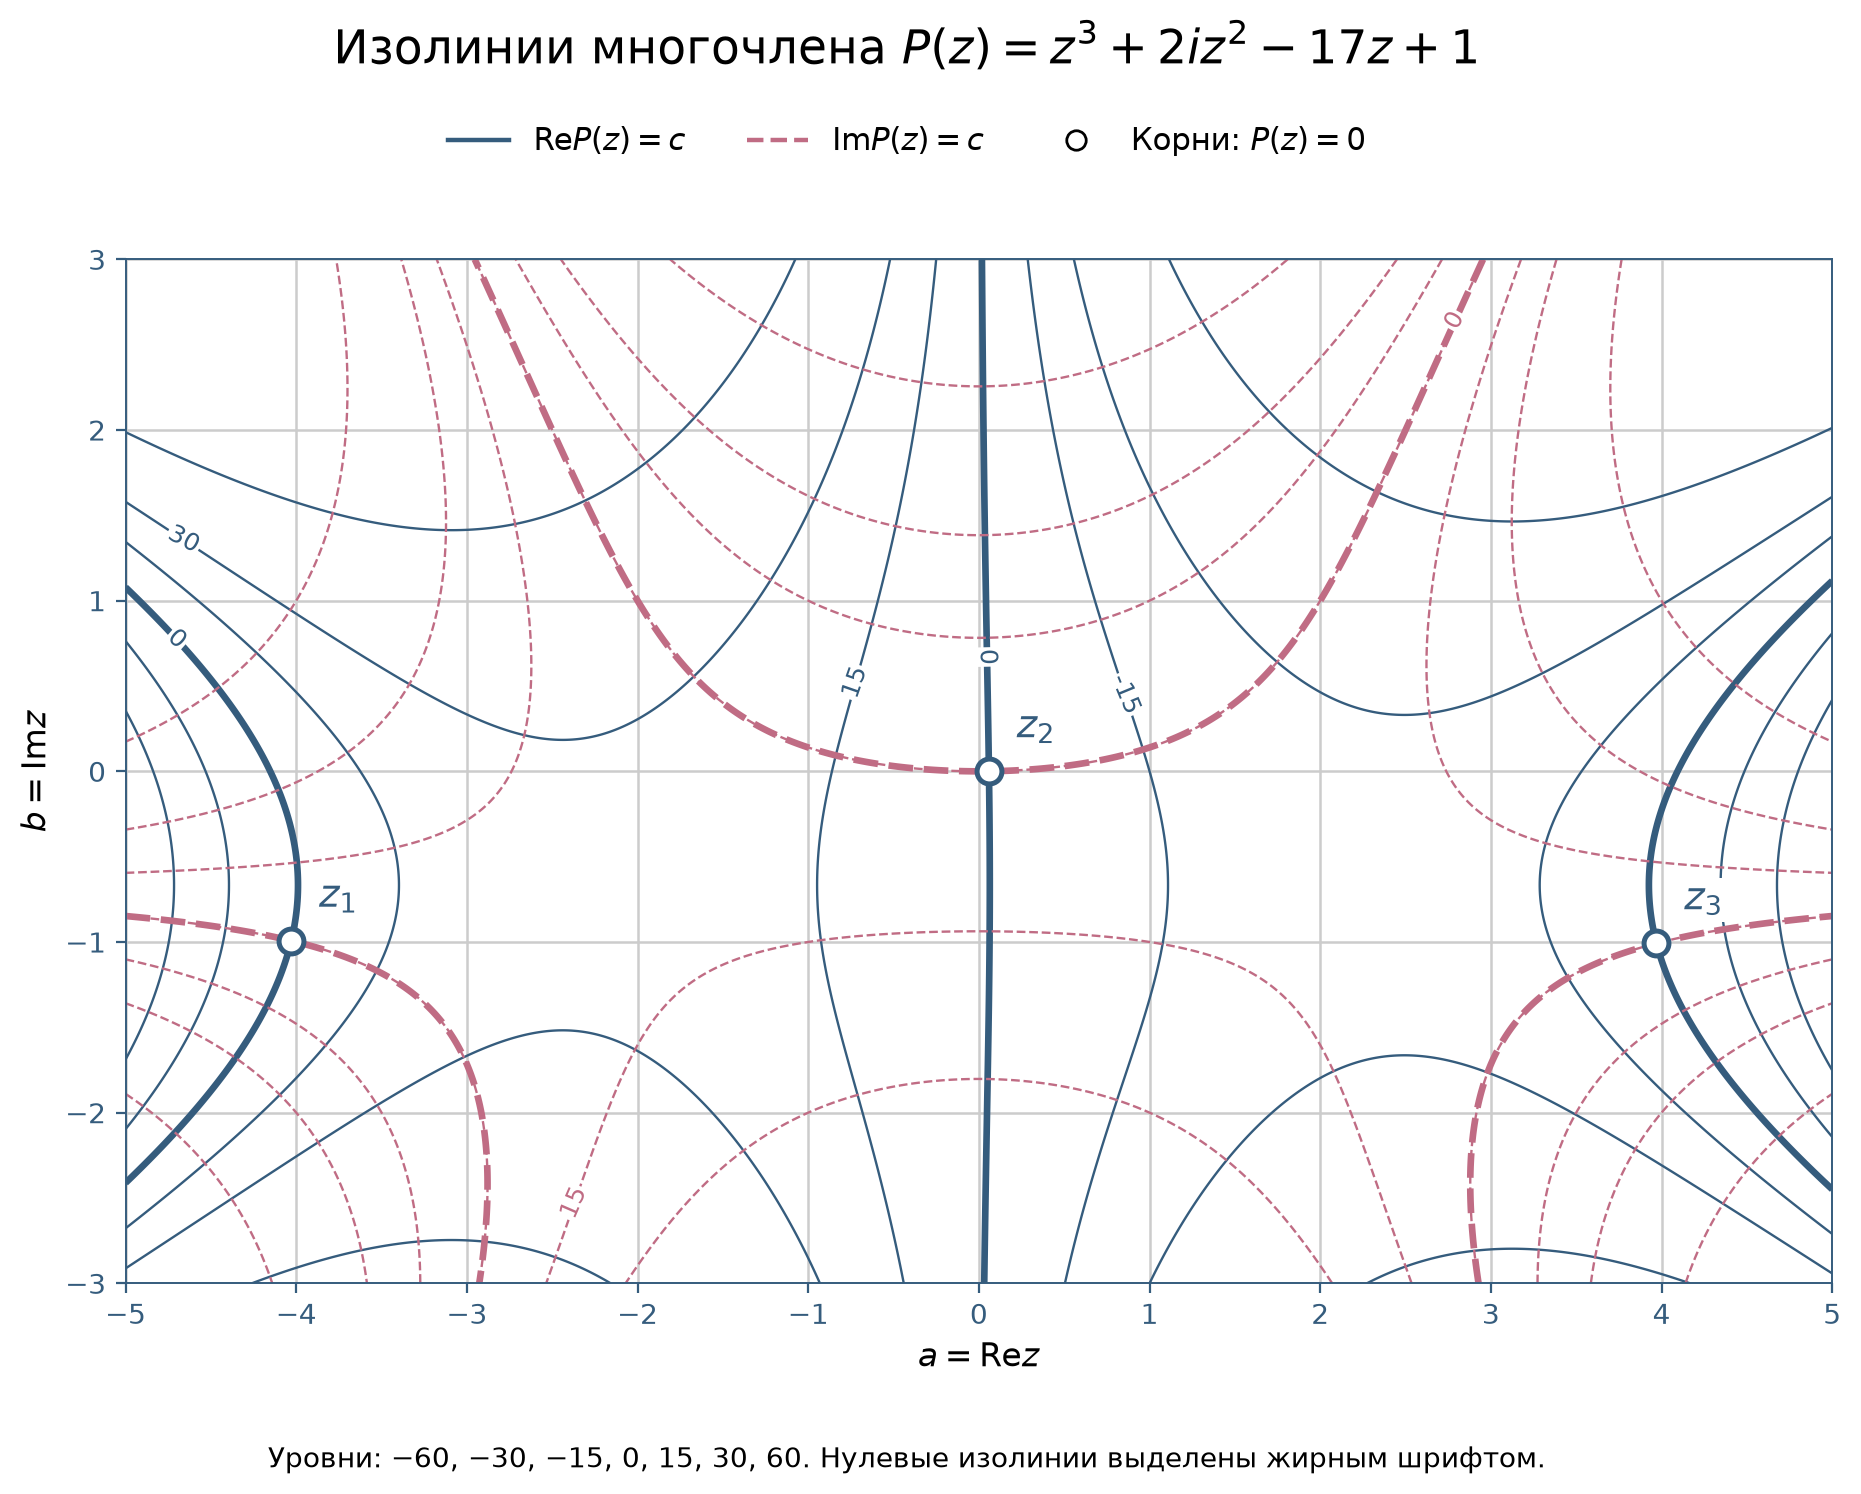

In [45]:
figure, axes = plt.subplots(figsize=(12, 8), facecolor=background)
axes.set_facecolor(background)
figure.subplots_adjust(left=0.09, right=0.97, bottom=0.17, top=0.81)

for values, color, style in [(U, maroon, "solid"), (V, red, "dashed")]:
    contours = axes.contour(
        A, B, values, levels=levels,
        colors=color, linewidths=0.85, linestyles=style,
    )
    labels = axes.clabel(contours, inline=False, fontsize=9, fmt="%d")
    for label in labels:
        x, y = label.get_position()

        if abs(x) > 4.7 or abs(y) > 2.7:
            label.set_visible(False)
        else:
            label.set_bbox(dict(facecolor=background, edgecolor="none", pad=0.6))

    axes.contour(
        A, B, values, levels=[0],
        colors=color, linewidths=2.4, linestyles=style,
    )

axes.scatter(
    roots.real, roots.imag,
    s=80, facecolor=background, edgecolor=maroon, linewidth=1.8, zorder=5,
)
for j, z in enumerate(roots, start=1):
    axes.annotate(
        rf"$z_{j}$", (z.real, z.imag),
        xytext=(10, 12), textcoords="offset points", fontsize=14,
        color=maroon,
        bbox=dict(facecolor=background, edgecolor="none", pad=1),
    )

axes.set_xlim(a_min, a_max)
axes.set_ylim(b_min, b_max)
axes.set_aspect("equal", adjustable="box")
axes.set_xticks(np.arange(-5, 6, 1))
axes.set_yticks(np.arange(-3, 4, 1))
axes.set_xlabel(r"$a=\mathrm{Re}z$", fontsize=12, color="black")
axes.set_ylabel(r"$b=\mathrm{Im}z$", fontsize=12, color="black")
axes.tick_params(colors=maroon)
axes.grid(color=cream, linewidth=0.9)
axes.set_axisbelow(True)
for spine in axes.spines.values():
    spine.set_color(maroon)
    spine.set_linewidth(0.7)

figure.suptitle(
    r"Изолинии многочлена $P(z)=z^3+2iz^2-17z+1$",
    y=0.96, fontsize=17, color="black",
)
legend = [
    Line2D([0], [0], color=maroon, linewidth=1.6,
           label=r"$\mathrm{Re}P(z)=c$"),
    Line2D([0], [0], color=red, linestyle="--", linewidth=1.6,
           label=r"$\mathrm{Im}P(z)=c$"),
    Line2D([0], [0], color="black", linestyle="", marker="o",
           markerfacecolor=background, markersize=7, label=r"Корни: $P(z)=0$"),
]
figure.legend(
    handles=legend, loc="upper center", bbox_to_anchor=(0.5, 0.91),
    ncol=3, frameon=False, labelcolor="black", fontsize=11,
)
figure.text(
    0.5, 0.055,
    "Уровни: −60, −30, −15, 0, 15, 30, 60. Нулевые изолинии выделены жирным шрифтом.",
    ha="center", fontsize=10, color="black",
)

plt.show()

##### Комментарий к рисунку

На рисунке показаны два семейства изолиний и все три найденных корня. В каждой отмеченной точке пересекаются нулевая изолиния вещественной части и нулевая изолиния мнимой части:

$$
\mathrm{Re}P(z_j)=0,\qquad \mathrm{Im}P(z_j)=0.
$$

Поэтому $P(z_j)=0$. Значения корней вычислены приближённо; выше приведены результаты проверки подстановкой. Корень $z_2$ на этом масштабе почти совпадает с вещественной осью, однако его мнимая часть составляет примерно $0{,}0004074$.